In [26]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [27]:
words = open('names.txt','r').read().splitlines()

In [28]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
# print(itos)

In [38]:
vocab_size

27

In [29]:
g = torch.Generator(device=device).manual_seed(2147483647)

In [30]:

block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    return X, Y

random.seed(47)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtes, Ytes = build_dataset(words[n2:])

In [31]:
Ytr[0]

tensor(11, device='cuda:0')

In [32]:
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f"{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | max diff: {maxdiff}")

In [33]:
n_embd = 10
n_hidden = 64

g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g, device=device)

#layer1
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g, device=device)*((5/3)/((n_embd*block_size)**0.5))
b1 = torch.randn(n_hidden, generator=g, device=device) * 0.1

#layer2
w2 = torch.randn((n_hidden, vocab_size), generator=g, device=device)*0.1
b2 = torch.randn((vocab_size,), generator=g, device=device)*0.1

#batch_normalization parameters
bngain = torch.randn((1, n_hidden), device=device)*0.1 + 1.0
bnbias = torch.randn((1, n_hidden), device=device)*0.1

parameters = [C, W1, b1, w2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

4137


In [34]:
batch_size = 32
n = batch_size

ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device=device)
Xb, Yb = Xtr[ix], Ytr[ix]

In [35]:
ix

tensor([ 71595,  34480, 129268, 112500, 166236, 148122, 116200, 144530, 105578,
         76929, 140311,  21140, 139822, 121790, 102735,  94976, 171190,  81608,
        139863,  28502,  88872, 135448,  40541,  49666, 106869, 181962,  88735,
        116282,  34368,  41126,  30150, 154431], device='cuda:0')

In [42]:
embcat.shape

torch.Size([32, 30])

In [94]:
emb = C[Xb]                                                      #look up the embeddings for the batch, resulting in a (batch_size, block_size, n_embd) tensor
embcat = emb.view(emb.shape[0], -1)                              # concatenate the embeddings into a (batch_size, block_size*n_embd) tensor

hprebn = embcat @ W1 + b1                                        # linear layer, resulting in (batch_size, n_hidden) tensor

bnmeani = 1/n * hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1) * (bndiff2).sum(0, keepdim=True)
bnvar_inv = 1.0 / (bnvar + 1e-5)**0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

h = torch.tanh(hpreact)

logits = h @ w2 + b2
loss_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - loss_maxes
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = (counts_sum**-1)
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

for p in parameters:
    p.grad = None

for t in [logprobs, probs, counts_sum_inv, counts_sum, counts, norm_logits, loss_maxes, logits, h, hpreact, bnraw, bnvar_inv, bnvar, bndiff2, bndiff, bnmeani]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3049, device='cuda:0', grad_fn=<NegBackward0>)

In [95]:
print(f"counts_sum: {counts_sum_inv.shape}, probs: {probs.shape}, logprobs: {logprobs.shape}, h: {h.shape}, w2: {w2.shape}, b2: {b2.shape}, hpreact: {hpreact.shape}, bnraw: {bnraw.shape}, bnvar_inv: {bnvar_inv.shape}, bnvar: {bnvar.shape}, bndiff2: {bndiff2.shape}, bndiff: {bndiff.shape}, bnmeani: {bnmeani.shape}")

counts_sum: torch.Size([32, 1]), probs: torch.Size([32, 27]), logprobs: torch.Size([32, 27]), h: torch.Size([32, 64]), w2: torch.Size([64, 27]), b2: torch.Size([27]), hpreact: torch.Size([32, 64]), bnraw: torch.Size([32, 64]), bnvar_inv: torch.Size([1, 64]), bnvar: torch.Size([1, 64]), bndiff2: torch.Size([32, 64]), bndiff: torch.Size([32, 64]), bnmeani: torch.Size([1, 64])


In [101]:

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n

dprob = dlogprobs * (probs**-1) 
dcounts_sum_inv = (dprob*counts).sum(1, keepdim=True)
dcounts_sum = dcounts_sum_inv * (-counts_sum**-2)
dcounts = dprob * counts_sum_inv + dcounts_sum
dnorm_logits = dcounts * norm_logits.exp()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits = dnorm_logits + F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

cmp("dlogprobs", dlogprobs, logprobs)
cmp("dprod", dprob, probs)
cmp("dcounts_sum_inv", dcounts_sum_inv, counts_sum_inv)
cmp("dcounts_sum", dcounts_sum, counts_sum)
cmp("counts", dcounts, counts)
cmp("dnorm_logits", dnorm_logits, norm_logits)
cmp("dlogit_maxes", dlogit_maxes, loss_maxes)
cmp("dlogits", dlogits, logits)

dlogprobs       | exact: True  | approximate: True  | max diff: 0.0
dprod           | exact: True  | approximate: True  | max diff: 0.0
dcounts_sum_inv | exact: True  | approximate: True  | max diff: 0.0
dcounts_sum     | exact: True  | approximate: True  | max diff: 0.0
counts          | exact: True  | approximate: True  | max diff: 0.0
dnorm_logits    | exact: True  | approximate: True  | max diff: 0.0
dlogit_maxes    | exact: True  | approximate: True  | max diff: 0.0
dlogits         | exact: True  | approximate: True  | max diff: 0.0


In [98]:
logits.shape

torch.Size([32, 27])

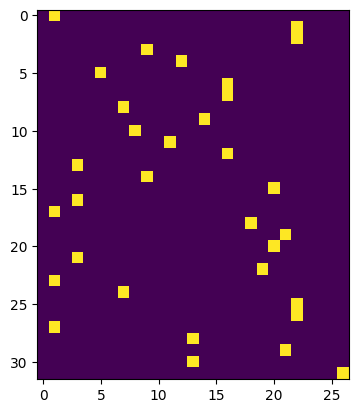

In [104]:
plt.imshow(F.one_hot(logits.max(1).indices.cpu(), num_classes=logits.shape[1]))